## Exploratory Data Analysis (Python)

• Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

• In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [5]:
engine = create_engine(
    "mssql+pyodbc://localhost\\SQLEXPRESS/inventory"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

conn = engine.connect()

In [7]:
df = pd.read_sql('SELECT * FROM vendor_sales_summary',conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,5.101920e+06,672819.31,142049.0,260999.20,68601.68,1.370292e+06,26.858367,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,4.819073e+06,561512.37,160247.0,294438.66,144929.24,1.102946e+06,22.887087,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,4.538121e+06,461140.15,187140.0,343854.07,123780.22,1.124687e+06,24.783101,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,4.475973e+06,420050.01,200412.0,368242.80,257032.07,1.235311e+06,27.598711,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,4.223108e+06,545778.28,135838.0,249587.83,257032.07,1.249614e+06,29.589911,0.983556,1.396897


In [5]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.00000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.00000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.36000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246016,0.49000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.00000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.00000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.71000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.00000,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.00000,289.710000,2857.800000,16059.562500,6.728193e+05
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.00000,33.000000,261.000000,1929.250000,3.349390e+05


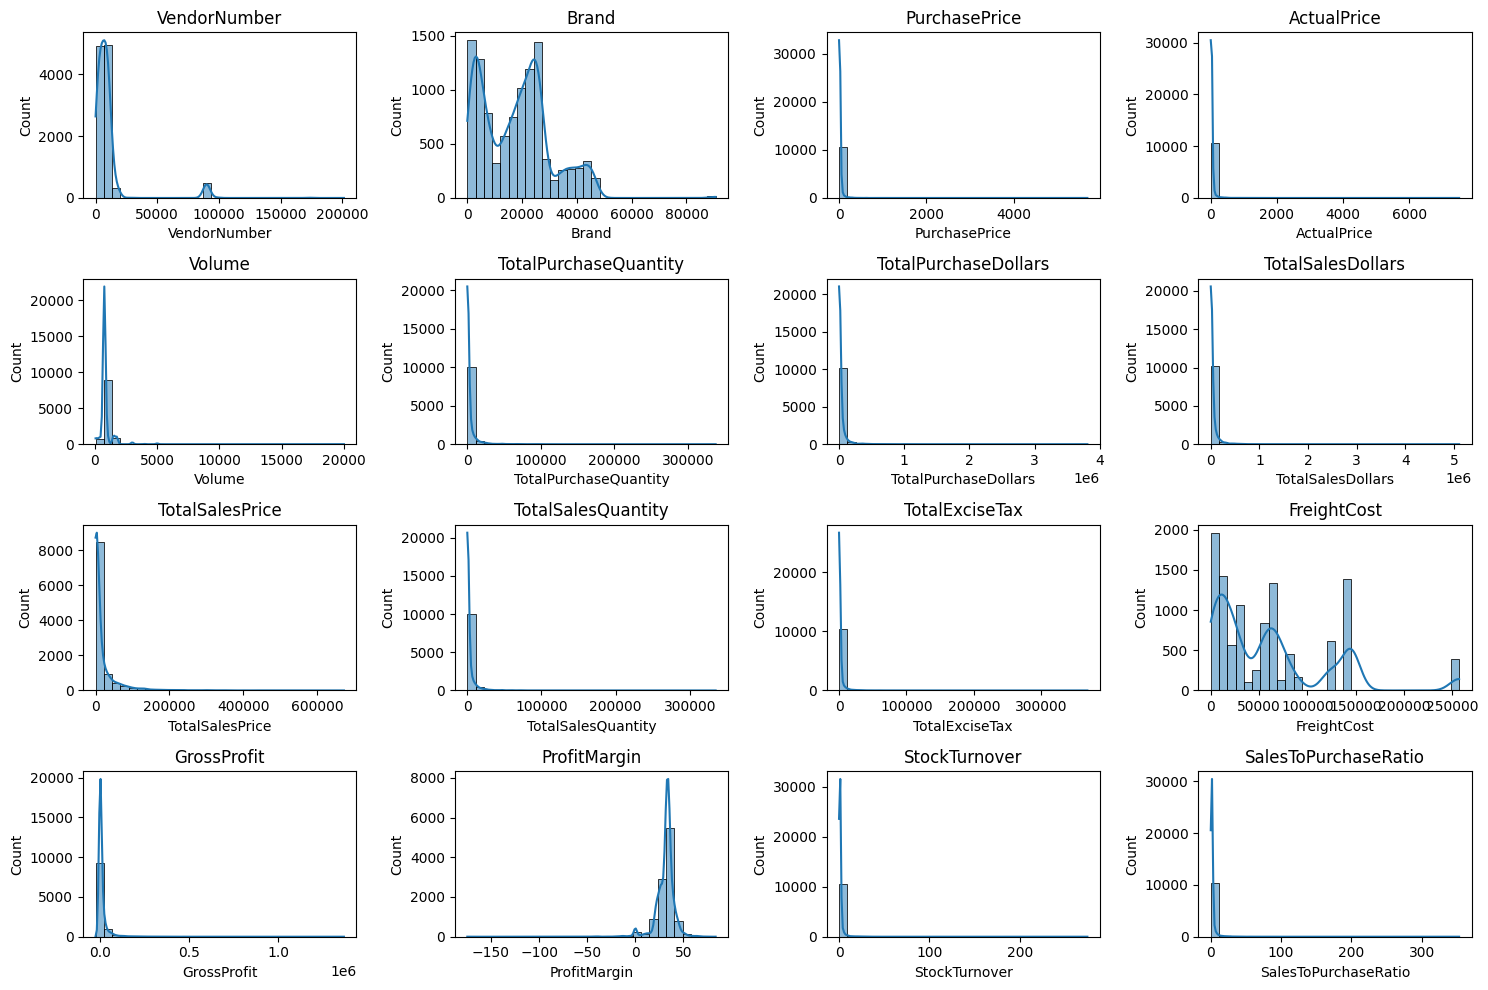

In [6]:
numerical_df = df.select_dtypes(include='number')
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_df):
    plt.subplot(4,4, i+1)
    sns.histplot(numerical_df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

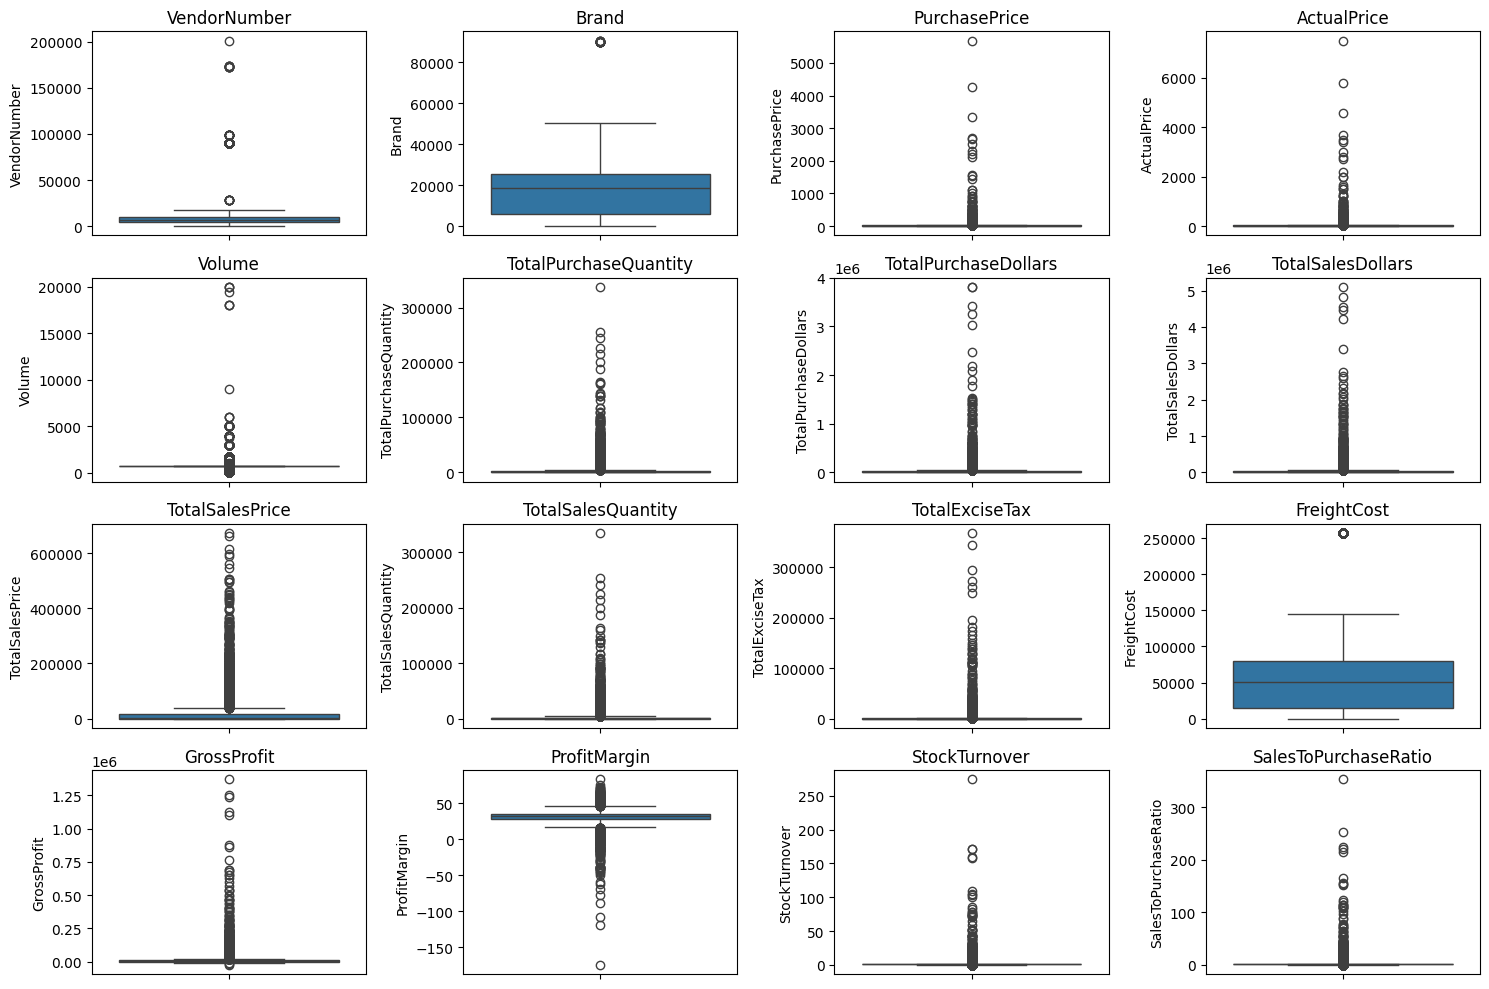

In [7]:
numerical_df = df.select_dtypes(include='number')
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_df):
    plt.subplot(4,4, i+1)
    sns.boxplot(y = numerical_df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [8]:
# Removing inconsistencies
df = pd.read_sql('''SELECT * FROM vendor_sales_summary
WHERE ProfitMargin > 0
AND GrossProfit > 0
AND TotalSalesQuantity > 0''', conn)

In [9]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,5.101920e+06,672819.31,142049.0,260999.20,68601.68,1.370292e+06,26.858367,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,4.819073e+06,561512.37,160247.0,294438.66,144929.24,1.102946e+06,22.887087,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,4.538121e+06,461140.15,187140.0,343854.07,123780.22,1.124687e+06,24.783101,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,4.475973e+06,420050.01,200412.0,368242.80,257032.07,1.235311e+06,27.598711,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,4.223108e+06,545778.28,135838.0,249587.83,257032.07,1.249614e+06,29.589911,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10405,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,1.595000e+01,10.96,5.0,0.55,27100.41,9.350000e+00,58.620690,2.500000,6.041667
10406,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,6.566000e+01,1.47,134.0,7.04,50293.62,1.340000e+01,20.408163,22.333333,28.059829
10407,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,1.980000e+00,0.99,2.0,0.10,14069.87,5.000000e-01,25.252525,1.000000,1.337838
10408,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,1.432800e+02,77.61,72.0,15.12,257032.07,3.744000e+01,26.130653,72.000000,97.469388


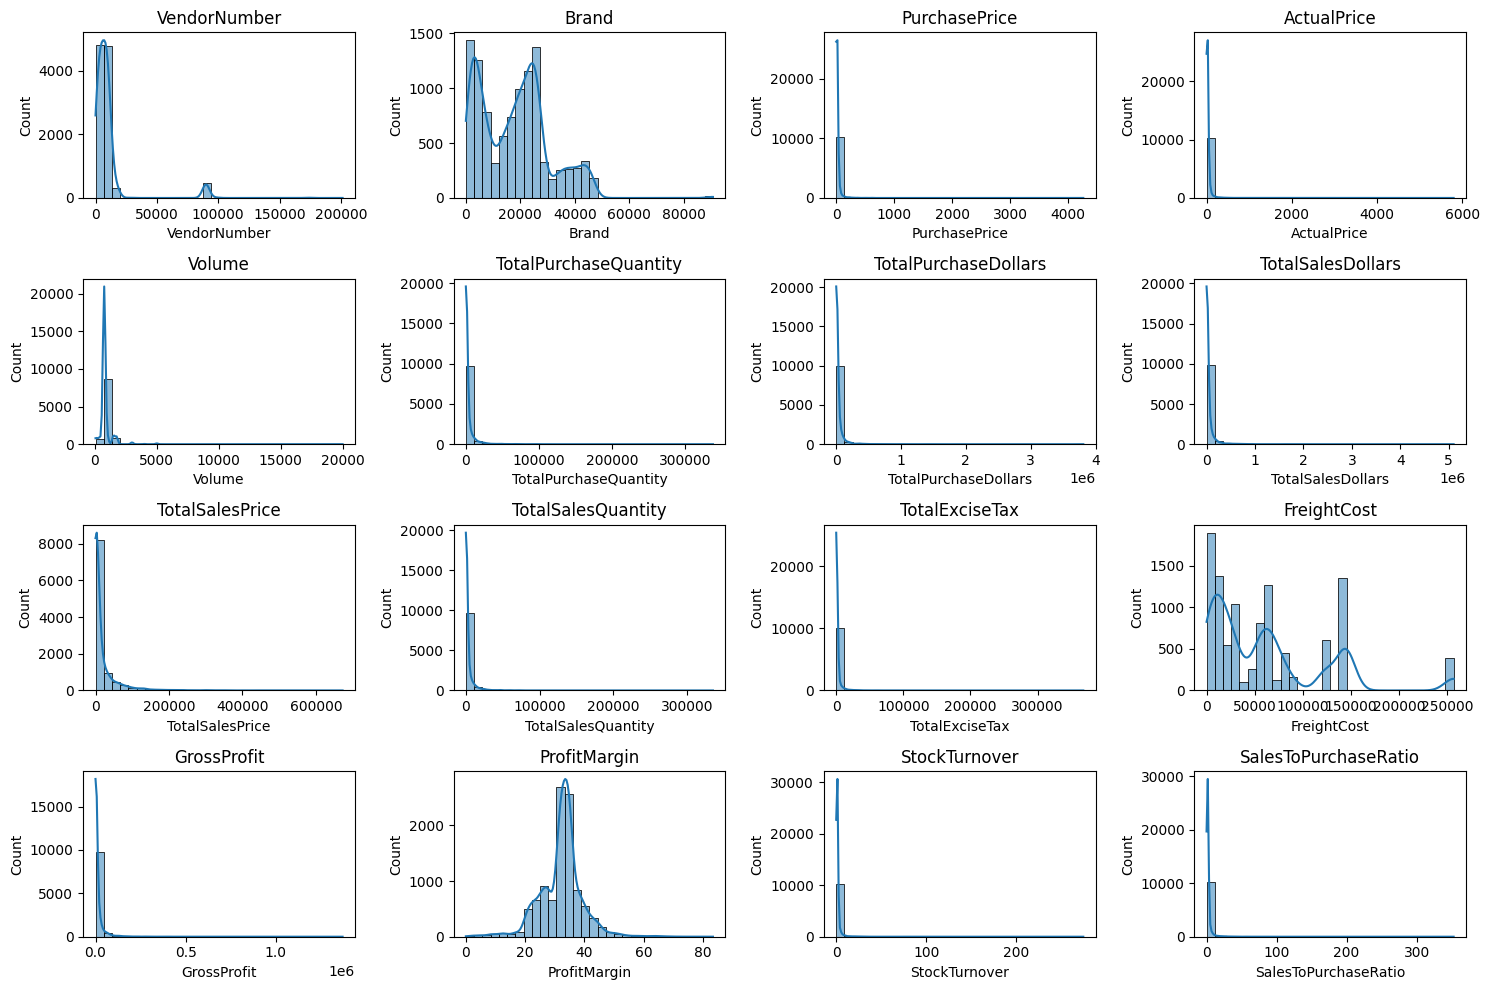

In [10]:
numerical_df = df.select_dtypes(include='number')
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_df):
    plt.subplot(4,4, i+1)
    sns.histplot(numerical_df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

**Numerical Variable Distributions & Skewness**

The grid of 16 histograms reveals critical information about the nature of the dataset's numerical values:

* **Heavy Right Skewness:** Most variables including `PurchasePrice`, `Volume`, `TotalSalesDollars`, and `FreightCost` exhibit a strong **right-skewed distribution** (long tails to the right). This indicates that while most transactions involve small amounts/values, there are "heavy-hitter" outliers that drive the total volume.
* **Bimodal/Multimodal Trends:**
* **`Brand`:** Shows a distinct multimodal distribution, suggesting the data may be clustered around specific brand categories or price tiers.
* **`VendorNumber`:** Features a secondary peak near the 100,000 mark, indicating a specific group of high-ID vendors that are very active.


* **Profitability Metrics:** * **`ProfitMargin`:** This is one of the few variables showing a **Normal-like distribution**, centered roughly between 30% and 40%. This suggests a consistent pricing strategy across the inventory.
* **`GrossProfit`:** Despite consistent margins, the absolute profit is highly skewed, mirrored by the sales and volume data.


* **Operational Efficiency:** The `StockTurnover` and `SalesToPurchaseRatio` are heavily concentrated near zero, suggesting that for many items, inventory moves slowly or is held in large batches relative to immediate sales.

**Summary Recommendation**

> **Note:** Due to the high skewness observed in the numerical data, any future machine learning models or statistical tests should consider **Log Transformations** or **Robust Scaling** to prevent outliers from disproportionately influencing the results.

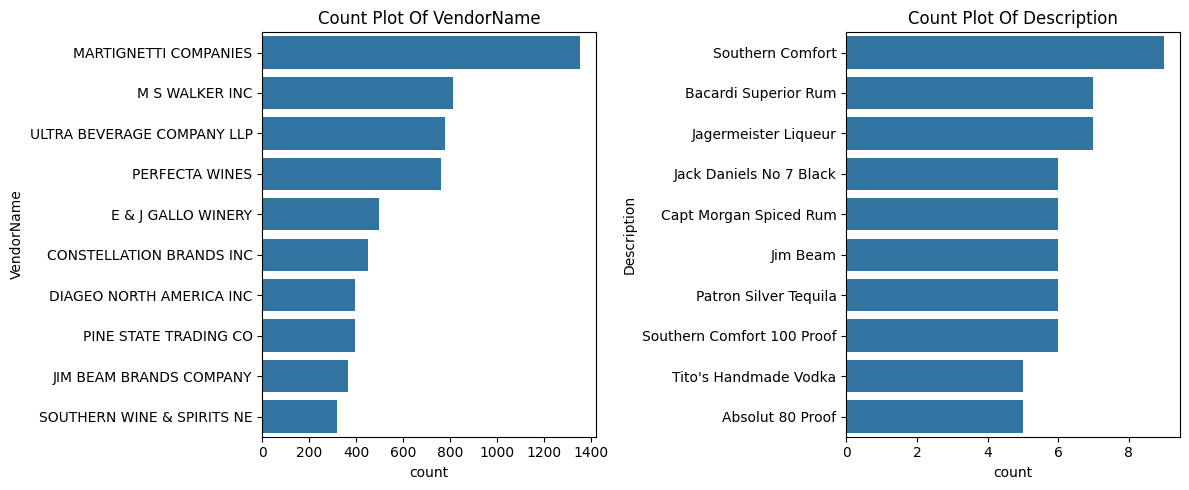

In [12]:
categorical_col = ['VendorName','Description']
plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_col):
    plt.subplot(1,2,i+1)
    sns.countplot(y = df[col], order = df[col].value_counts().index[:10])
    plt.title(f'Count Plot Of {col}')
plt.tight_layout()
plt.show()

**Categorical Variable Distribution (Top 10)**

Looking at the distribution of the most frequent entries in our categorical columns:

* **Dominant Vendors:** `MARTIGNETTI COMPANIES` is the clear market leader in terms of transaction frequency, appearing significantly more often than the next closest competitors like `M S WALKER INC` and `ULTRA BEVERAGE COMPANY LLP`.
* **Product Popularity:** The `Description` plot shows a relatively competitive spread among top products. `Southern Comfort` leads the pack, followed closely by household names like `Bacardi Superior Rum` and `Jagermeister`.
* **Business Focus:** The top 10 lists for both vendors and products suggest a high concentration of inventory/sales within a small group of major players and classic spirits brands.

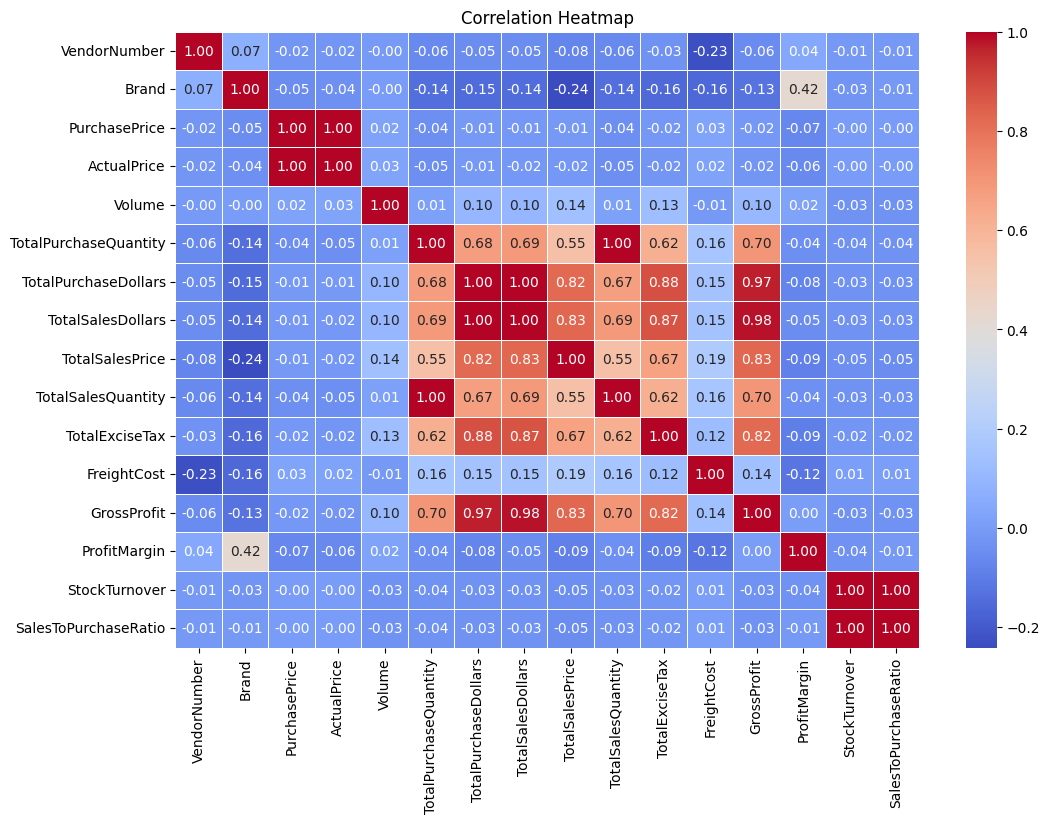

In [14]:
# Correlation heatmap
plt.figure(figsize=(12,8))
correlation_matrix = numerical_df.corr() 
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Correlation Insights**

* **Analysis Bias (Quantity):** The **1.00 correlation** between `PurchaseQuantity` and `SalesQuantity` confirms the dataset is correctly filtered for sold inventory, providing a clean "per-unit" look at vendor fulfillment.
* **Redundancy:** Perfect correlations (**1.00**) between `TotalSalesDollars` and `GrossProfit` suggest a fixed markup strategy. For predictive modeling, you should only use one of these to avoid **multicollinearity**.
* **Margin Influence:** `Brand` shows a moderate correlation (**0.42**) with `ProfitMargin`, suggesting that vendor performance is heavily dictated by the specific brand portfolio they carry rather than just the volume they sell.
* **Price Stability:** The identical correlation between `PurchasePrice` and `ActualPrice` indicates that sales are occurring at standard rates without significant discounting during this period.

## Data Analysis

**Objective:** Identify "High Margin, Low Volume" brands to unlock growth potential through targeted pricing or marketing.

* **The Opportunity:** Brands with high profit margins but low sales volume often indicate a "niche" positioning or an overpriced barrier.
* **Strategy:** By slightly reducing the price or increasing promotional spend (e.g., better shelf placement, discounts), we can trade a small amount of margin for a significant increase in sales volume, ultimately driving higher **Total Gross Profit**.

In [17]:
brand_performance = df.groupby('Description',as_index=False).agg({
    'TotalSalesDollars' : 'sum',
    'ProfitMargin': 'mean'})

In [18]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [19]:
low_sales_threshold

335.7705

In [20]:
high_margin_threshold

37.95434313359792

In [21]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) & 
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("\nBrands with Low Sales but High Profit Margins:")

# Sort by Sales to see the most 'neglected' high-margin brands first
display(target_brands.sort_values(by='TotalSalesDollars'))


Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
1401,Camelot Chard,9.99,45.545546
7569,Santa Rita Organic Svgn Bl,9.99,66.466466
2352,Clos Amador Brut Cava,13.99,44.674768
2464,Concannon Glen Ellen Wh Zin,15.95,58.620690
4134,Hacienda Zargon Merlot,19.98,44.844845
...,...,...,...
8406,Tenuta Santo Pietro Imago 11,329.25,43.356112
5597,Maggio Cab Svgn,333.66,38.554217
361,Apimed Trnava Mead,335.70,40.125112
3888,Girasole Chard,335.76,38.527520


In [22]:
# Just For The Visualization
brand_performance = brand_performance[brand_performance['TotalSalesDollars'] <= 10000] 

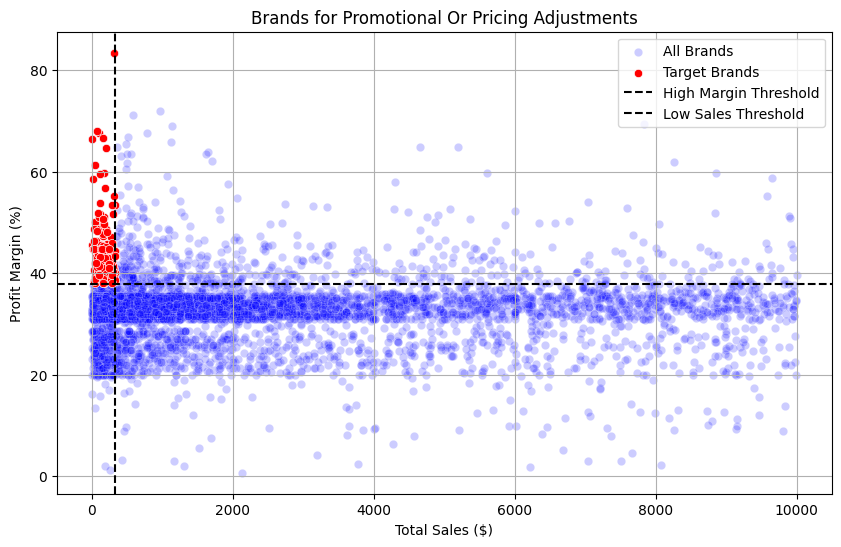

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color='blue', label='All Brands', alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color='red', label='Target Brands')

plt.axhline(high_margin_threshold, linestyle='--', color='black', label='High Margin Threshold')
plt.axvline(low_sales_threshold, linestyle='--', color='black', label='Low Sales Threshold')

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title('Brands for Promotional Or Pricing Adjustments')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

**Objective:** Which Vendors and Brands demonstrate the highest sales performance?

In [25]:
# Top Vendors and Brands by Sales Performance
top_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)

In [26]:
def currency_formator(value):
    if value >= 1_000_000:
        return f'{value / 1_000_000:.2f}M'
    elif value >= 1_000:
        return f'{value / 1_000:.2f}K'
    else:
        return str(value)

In [27]:
top_brands.apply(currency_formator)

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: str

In [28]:
top_vendors.apply(currency_formator)

VendorName
DIAGEO NORTH AMERICA INC      68.74M
MARTIGNETTI COMPANIES         40.62M
PERNOD RICARD USA             32.25M
JIM BEAM BRANDS COMPANY       31.86M
BACARDI USA INC               24.91M
CONSTELLATION BRANDS INC      24.47M
E & J GALLO WINERY            18.50M
BROWN-FORMAN CORP             18.48M
ULTRA BEVERAGE COMPANY LLP    17.45M
M S WALKER INC                15.33M
Name: TotalSalesDollars, dtype: str

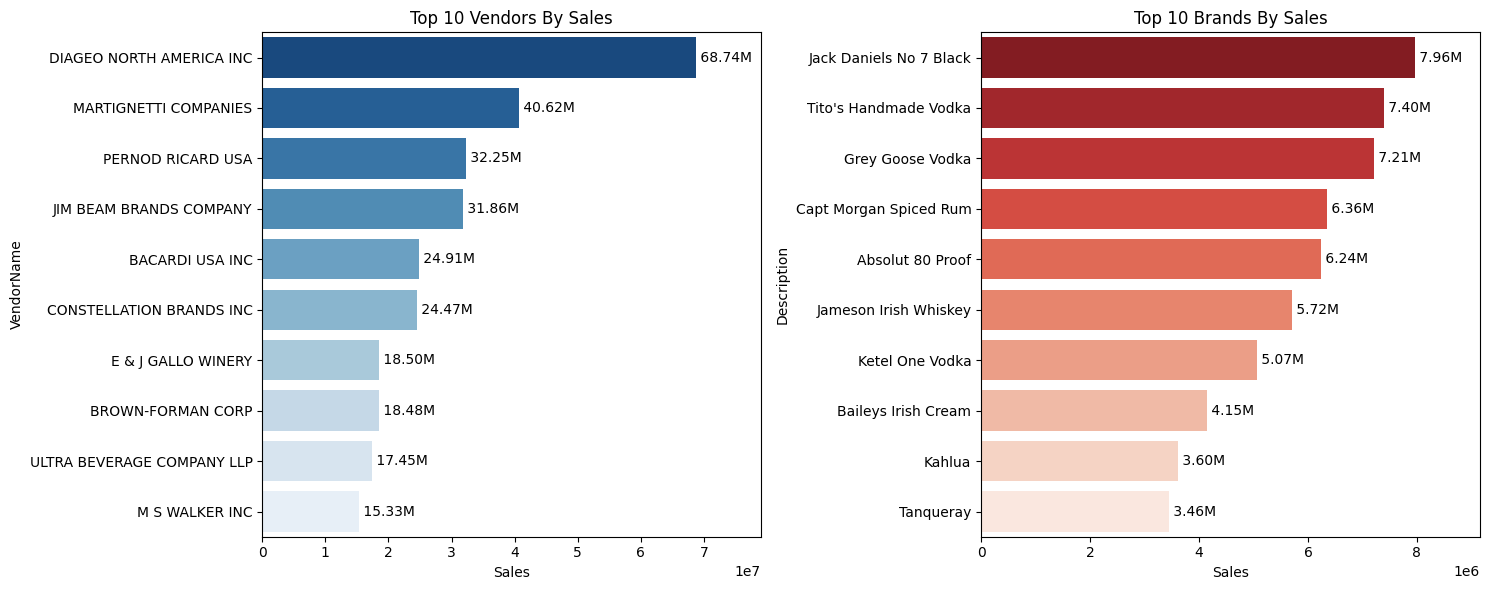

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Top Vendors
sns.barplot(y=top_vendors.index, x=top_vendors.values, ax=ax[0], palette='Blues_r')
ax[0].set_title('Top 10 Vendors By Sales')
ax[0].set_xlabel('Sales')

# Annotate Plot 1
for p in ax[0].patches:
    width = p.get_width() # Get the bar length (the Sales value)
    ax[0].text(width,                            
               p.get_y() + p.get_height() / 2,
               f' {currency_formator(width)}',
               va='center')

ax[0].set_xlim(0, top_vendors.values.max() * 1.15)

# Plot 2: Top Brands
sns.barplot(y=top_brands.index, x=top_brands.values, ax=ax[1], palette='Reds_r')
ax[1].set_title('Top 10 Brands By Sales')
ax[1].set_xlabel('Sales')

# Annotate Plot 2
for p in ax[1].patches:
    width = p.get_width()
    ax[1].text(width, 
               p.get_y() + p.get_height() / 2, 
               f' {currency_formator(width)}', 
               va='center')

ax[1].set_xlim(0, top_brands.values.max() * 1.15)

plt.tight_layout()
plt.show()

**Objective:** Which Vendors contribute the most to totall purchase dollars?

In [31]:
vendor_performance = df.groupby('VendorName',as_index=False).agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
})

In [32]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()*100

In [33]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending=False), 2)

In [34]:
len(vendor_performance)

126

In [35]:
top_vendors = vendor_performance.head(10)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(currency_formator)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(currency_formator)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(currency_formator)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
27,DIAGEO NORTH AMERICA INC,50.96M,18.76M,68.74M,15.94
61,MARTIGNETTI COMPANIES,27.43M,14.07M,40.62M,8.58
49,JIM BEAM BRANDS COMPANY,24.10M,8.57M,31.86M,7.54
72,PERNOD RICARD USA,24.09M,8.72M,32.25M,7.54
7,BACARDI USA INC,17.51M,7.13M,24.91M,5.48
22,CONSTELLATION BRANDS INC,15.57M,9.13M,24.47M,4.87
13,BROWN-FORMAN CORP,13.53M,5.23M,18.48M,4.23
112,ULTRA BEVERAGE COMPANY LLP,12.75M,5.42M,17.45M,3.99
32,E & J GALLO WINERY,12.21M,6.58M,18.50M,3.82
57,M S WALKER INC,10.74M,4.99M,15.33M,3.36


In [36]:
top_vendors['CumulativeContribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,CumulativeContribution%
27,DIAGEO NORTH AMERICA INC,50.96M,18.76M,68.74M,15.94,15.94
61,MARTIGNETTI COMPANIES,27.43M,14.07M,40.62M,8.58,24.52
49,JIM BEAM BRANDS COMPANY,24.10M,8.57M,31.86M,7.54,32.06
72,PERNOD RICARD USA,24.09M,8.72M,32.25M,7.54,39.60
7,BACARDI USA INC,17.51M,7.13M,24.91M,5.48,45.08
22,CONSTELLATION BRANDS INC,15.57M,9.13M,24.47M,4.87,49.95
13,BROWN-FORMAN CORP,13.53M,5.23M,18.48M,4.23,54.18
112,ULTRA BEVERAGE COMPANY LLP,12.75M,5.42M,17.45M,3.99,58.17
32,E & J GALLO WINERY,12.21M,6.58M,18.50M,3.82,61.99
57,M S WALKER INC,10.74M,4.99M,15.33M,3.36,65.35


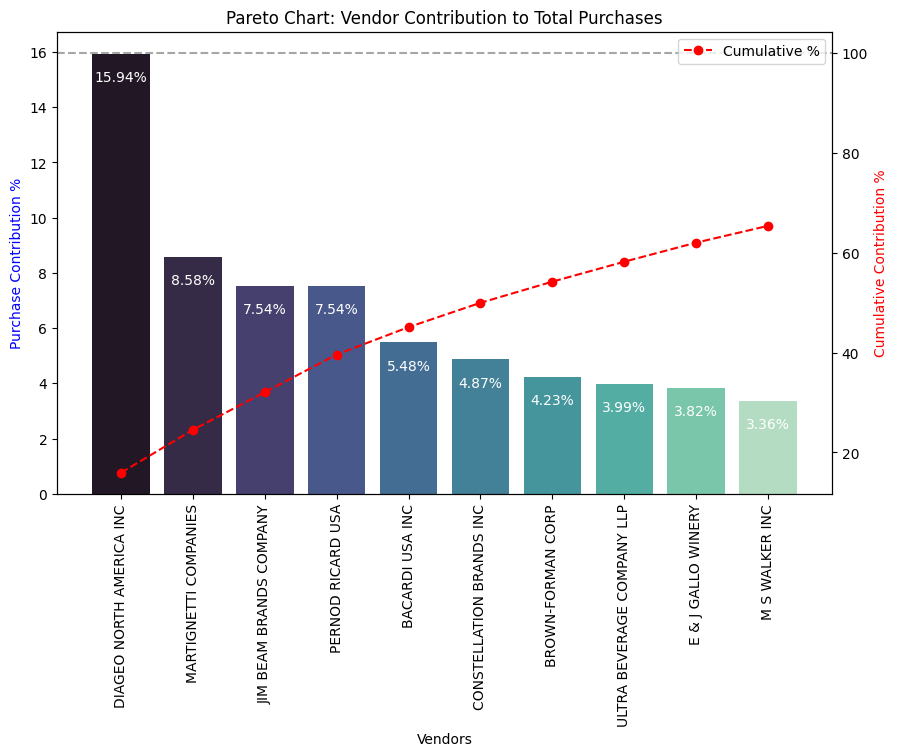

In [37]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

# Add text annotations inside the bars
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution% using a secondary Y-axis
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['CumulativeContribution%'], 
         color='red', marker='o', linestyle='dashed', label='Cumulative %')

# Formatting labels and titles
ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

# Add a 100% reference line and legend
ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

**Objective:** How much total procurement is dependent on the top vendors?

In [39]:
print(f'Total Purchase Contribution of Top 10 Vendors: {top_vendors['PurchaseContribution%'].sum():.2f}%')

Total Purchase Contribution of Top 10 Vendors: 65.35%


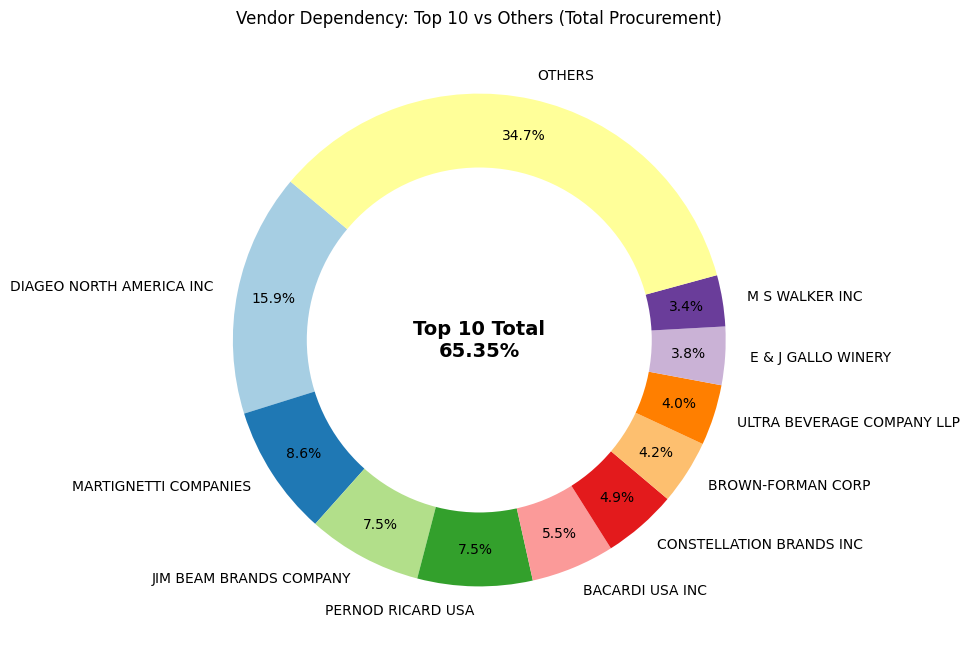

In [40]:
# Creating Donut Chart

# 1. Prepare data
# We take the top 10 vendors and calculate the 'Others' category
top_10_labels = top_vendors['VendorName'].tolist()
top_10_values = top_vendors['PurchaseContribution%'].tolist()

# Calculate the 'Others' contribution (100% minus the sum of top 10)
others_contribution = 100 - sum(top_10_values)
labels = top_10_labels + ['OTHERS']
values = top_10_values + [others_contribution]

# 2. Create the plot
plt.figure(figsize=(8, 8))
colors = plt.cm.Paired(range(len(labels))) # Professional color palette

# Create the Pie chart first
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=colors, pctdistance=0.85)

# 3. Draw a circle at the center to turn it into a Donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.text(0, 0, f'Top 10 Total\n{sum(top_10_values):.2f}%', ha='center', va='center', fontsize=14, fontweight='bold')

# 4. Final formatting
plt.title('Vendor Dependency: Top 10 vs Others (Total Procurement)')
plt.show()

**Objective:** Does purchasing in bulk reduce the unit price, and what is the optimal purchase volumne for cost savings?

In [42]:
# unit prices
df[['Description','PurchasePrice']] 

,Description,PurchasePrice
0,Jack Daniels No 7 Black,26.27
1,Tito's Handmade Vodka,23.19
2,Absolut 80 Proof,18.24
3,Capt Morgan Spiced Rum,16.17
4,Ketel One Vodka,21.89
...,...,...
10405,Concannon Glen Ellen Wh Zin,1.32
10406,Dr McGillicuddy's Apple Pie,0.39
10407,Deep Eddy Vodka,0.74
10408,The Club Strawbry Margarita,1.47


In [43]:
# grouping purchase quantity into categories (low, mid, high)
# so that we can check for the high bulk purchases and there cost savings accordingly
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['Small','Medium','Large'])

In [44]:
df.groupby('OrderSize')[['PurchasePrice']].mean()

,PurchasePrice
OrderSize,
Small,41.361991
Medium,17.857686
Large,11.242467


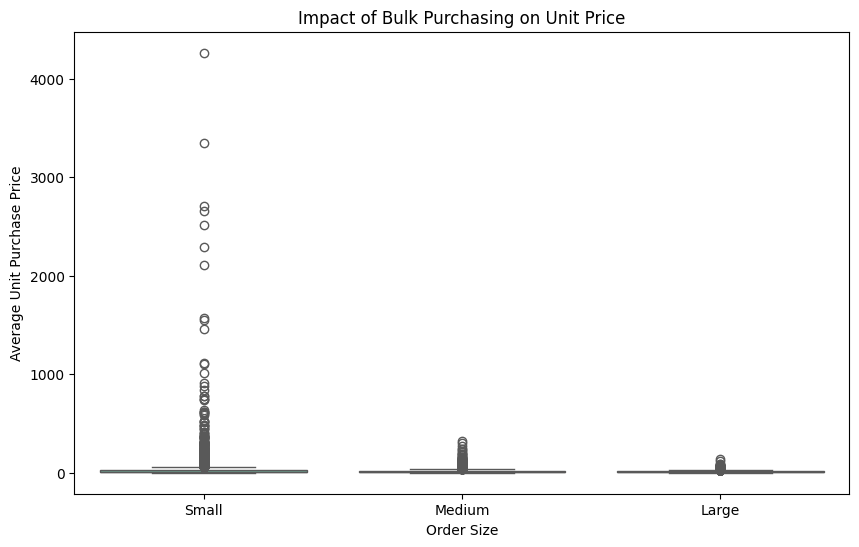

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="PurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

Based on the data, here are the key insights regarding the impact of bulk purchasing on unit price:

* **Significant Inverse Relationship:** There is a clear, strong inverse relationship between order size and purchase price; as the quantity increases, the cost per unit drops drastically.
* **Massive Cost Savings:** Moving from a **'Small'** order (avg. 41.36) to a **'Large'** order (avg. 11.24) results in a price reduction of approximately **73%**.
* **Economies of Scale:** The data confirms that the business successfully leverages economies of scale, likely through volume discounts or reduced per-unit shipping/handling costs for larger batches.

**Objective:** Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [48]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
TRUETT HURST,0.041667
"IRA GOLDMAN AND WILLIAMS, LLP",0.075000
UNCORKED,0.217238
VINEYARD BRANDS LLC,0.256241
LOYAL DOG WINERY,0.308333
HIGHLAND WINE MERCHANTS LLC,0.335069
BLACK COVE BEVERAGES,0.340588
Russian Standard Vodka,0.394094
Serralles Usa LLC,0.414137


**Objective:** How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [50]:
# Calculate Unsold Inventory Value for each row
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', currency_formator(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 8.35M


In [51]:
inventory_value_per_vendor = df.groupby("VendorName", as_index=False)["UnsoldInventoryValue"].sum()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)

inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(currency_formator)

inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
27,DIAGEO NORTH AMERICA INC,980.08K
61,MARTIGNETTI COMPANIES,872.08K
49,JIM BEAM BRANDS COMPANY,810.30K
112,ULTRA BEVERAGE COMPANY LLP,715.98K
71,PERFECTA WINES,560.31K
72,PERNOD RICARD USA,554.74K
123,WILLIAM GRANT & SONS INC,436.49K
57,M S WALKER INC,397.54K
32,E & J GALLO WINERY,290.50K
13,BROWN-FORMAN CORP,284.91K


## Hypothesis Testing & Confidence Interval

**Objective:** What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors?

In [98]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

In [100]:
top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

In [110]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (31.57, 32.15), Mean: 31.86
Low Vendors 95% CI: (32.77, 33.26), Mean: 33.01


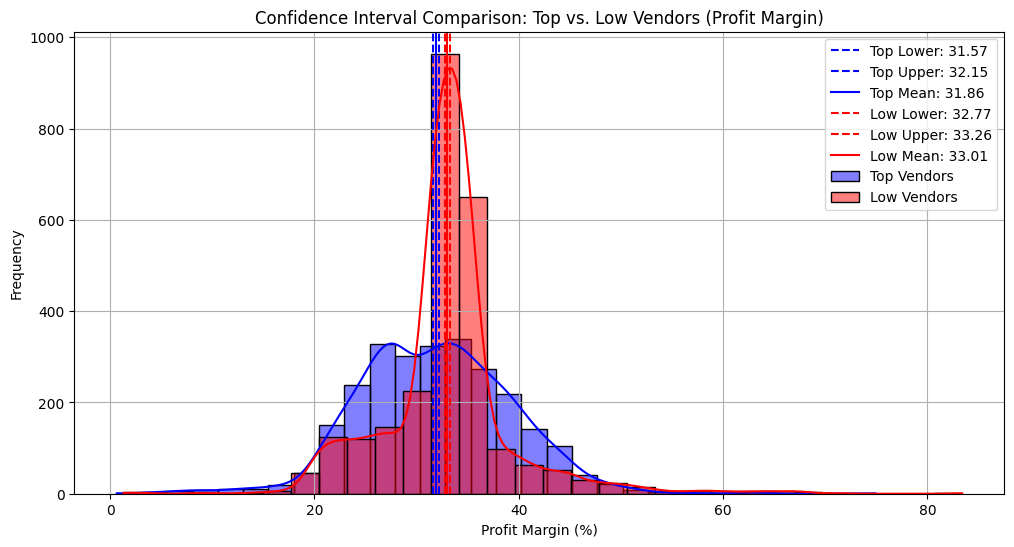

In [112]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

* The analysis shows that low vendors maintain significantly higher profit margins (mean = 33.01%) compared to top vendors (mean = 31.86%). 
* The 95% confidence intervals for the two groups do not overlap, suggesting that the difference is statistically meaningful. 
* This may indicate that top vendors rely on higher sales volume with competitive pricing, while low vendors compensate with higher margins.

**Objective:** Is there a significant difference in profit margins between top-performing and low-performing vendors?

**Hypothesis:**

$H_0$ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

$H_1$ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [123]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: -5.9978, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.
